# Case Study: Dự đoán số lượng lỗi phần mềm bằng Deep Learning

Notebook này được làm lại để bám sát **file hướng dẫn báo cáo khoa học** và bài báo **Predicting the Number of Software Faults using Deep Learning**.

**Bài toán:** dự đoán **số lượng lỗi phần mềm** trong từng class/module, không chỉ phân loại có lỗi/không lỗi.

**Project sử dụng:** chọn 3 project trong PROMISE `bug-data`:

- `lucene`
- `poi`
- `xalan`

**Phiên bản mặc định:** notebook ưu tiên các version xuất hiện trong bảng dataset của bài báo để phương pháp thử nghiệm sát tài liệu tham khảo chính hơn.

**Điểm cải tiến so với bản cũ**

1. Có checklist đối chiếu yêu cầu file Word.
2. Lọc đúng 3 project và version theo bài báo.
3. Triển khai SMOTEND-style sát thuật toán: dùng `k`, `m`, `r`, Minkowski distance, nội suy feature và nội suy target `bug`.
4. Có sơ đồ quy trình thực nghiệm.
5. Có mã giả/pseudocode.
6. Có phân tích data imbalance, correlation, MSE/Kendall, loss train/validation.
7. Có baseline DTR/SVR để so sánh với CNN/MLP.
8. Có phần tự sinh nhận xét cho report.
9. Có Threats to Validity và hướng phát triển.

## 0. Checklist theo yêu cầu báo cáo

| Yêu cầu trong file Word | Notebook đã xử lý ở đâu |
|---|---|
| Tóm tắt vấn đề và lý do dự đoán số lượng lỗi | Phần giới thiệu và gợi ý report |
| CNN, MLP, SMOTEND | Phần xây dựng mô hình và SMOTEND-style |
| Dataset và software metrics | Phần đọc dữ liệu, thống kê version, mô tả 20 metrics |
| Tiền xử lý dữ liệu | Clean missing/duplicate, log transform, standardization |
| Sơ đồ quy trình | Cell vẽ workflow |
| Mã giả | Cell pseudocode SMOTEND + pipeline |
| Kiến trúc mô hình | Model summary CNN/MLP, chia 5 nhóm feature |
| Siêu tham số | Cell cấu hình EPOCHS, BATCH_SIZE, learning rate |
| Biểu đồ loss train/validation | Cell vẽ loss và bảng overfitting diagnostics |
| So sánh trước/sau SMOTEND giữa CNN/MLP | Bảng kết quả deep learning |
| So sánh thêm baseline | DTR và SVR |
| Kết luận, hướng phát triển | Cell tự sinh nhận xét báo cáo |

## 1. Import thư viện và cấu hình môi trường

Nếu chạy trên Colab, nên upload thư mục `PROMISE-BACKUP/bug-data` hoặc mount Google Drive rồi sửa `BASE_PATH`.

In [1]:
from pathlib import Path
import re
import random
import warnings
import platform
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import NearestNeighbors
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

from scipy.stats import kendalltau

import tensorflow as tf
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, Concatenate, Conv1D, MaxPooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

print("Python:", platform.python_version())
print("TensorFlow:", tf.__version__)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

Python: 3.13.7
TensorFlow: 2.21.0
Pandas: 3.0.3
NumPy: 2.4.6


## 2. Khai báo dataset

Theo yêu cầu môn học, chỉ cần chọn **3 trong 12 project**. Notebook này chọn `lucene`, `poi`, `xalan`.

Để sát bài báo hơn, mặc định notebook chỉ lấy các version có trong bảng dataset của bài báo:

- Lucene: 2.0, 2.2, 2.4
- Poi: 1.5, 2.0, 3.0
- Xalan: 2.4, 2.5

Nếu muốn đọc toàn bộ version hiện có trong 3 folder, đổi `USE_PAPER_VERSION_FILTER = False`.

In [2]:
BASE_PATH = Path("PROMISE-BACKUP/bug-data")

PROJECTS = ["lucene", "poi", "xalan"]

PAPER_VERSION_FILTER = {
    "lucene": {"2.0", "2.2", "2.4"},
    "poi": {"1.5", "2.0", "3.0"},
    "xalan": {"2.4", "2.5"},
}

USE_PAPER_VERSION_FILTER = True

FEATURES = [
    "wmc", "dit", "noc", "cbo",
    "rfc", "lcom", "ca", "ce",
    "npm", "lcom3", "loc", "dam",
    "moa", "mfa", "cam", "ic",
    "cbm", "amc", "max_cc", "avg_cc"
]
TARGET = "bug"

OUTPUT_DIR = Path("outputs_promise_fault_prediction_9_5")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Base path:", BASE_PATH.resolve())
print("Projects:", PROJECTS)
print("Use paper version filter:", USE_PAPER_VERSION_FILTER)
print("Output dir:", OUTPUT_DIR.resolve())

Base path: E:\Hoc Tap\HOC MAY_N\PROMISE-backup\bug-data
Projects: ['lucene', 'poi', 'xalan']
Use paper version filter: True
Output dir: E:\Hoc Tap\HOC MAY_N\outputs_promise_fault_prediction_9_5


## 3. Đọc và gộp dữ liệu từ PROMISE bug-data

Mỗi file CSV tương ứng với một version. Hàm dưới đây sẽ:

1. đọc từng folder project,
2. chuẩn hóa tên cột về chữ thường,
3. thêm cột `project`, `version`, `source_file`,
4. lọc version theo bài báo nếu `USE_PAPER_VERSION_FILTER = True`.

In [3]:
def extract_version_from_filename(file_path: Path, project: str) -> str:
    stem = file_path.stem.lower()
    prefix = project.lower() + "-"
    if stem.startswith(prefix):
        return stem.replace(prefix, "", 1)
    match = re.search(r"(\d+(?:\.\d+)*)", stem)
    return match.group(1) if match else stem


def load_selected_projects(
    base_path: Path,
    projects: list[str],
    version_filter: dict[str, set[str]] | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    all_frames = []
    file_summary = []

    if not base_path.exists():
        raise FileNotFoundError(
            f"Không tìm thấy thư mục: {base_path.resolve()}\n"
            "Hãy sửa BASE_PATH, ví dụ: Path('/content/PROMISE-backup/bug-data')"
        )

    for project in projects:
        folder = base_path / project
        if not folder.exists():
            raise FileNotFoundError(f"Không tìm thấy folder project: {folder.resolve()}")

        csv_files = sorted(folder.glob("*.csv"))
        if not csv_files:
            raise FileNotFoundError(f"Không tìm thấy CSV trong: {folder.resolve()}")

        for file_path in csv_files:
            version = extract_version_from_filename(file_path, project)

            if version_filter is not None:
                allowed_versions = version_filter.get(project, set())
                if version not in allowed_versions:
                    continue

            df = pd.read_csv(file_path)
            df.columns = [str(c).strip().lower() for c in df.columns]

            df["project"] = project
            df["version"] = version
            df["source_file"] = file_path.name

            all_frames.append(df)
            file_summary.append({
                "project": project,
                "version": version,
                "file": file_path.name,
                "rows": len(df),
                "columns": len(df.columns),
            })

    if not all_frames:
        raise ValueError(
            "Không đọc được file nào. Kiểm tra lại BASE_PATH hoặc đặt USE_PAPER_VERSION_FILTER = False."
        )

    raw_df = pd.concat(all_frames, ignore_index=True)
    summary_df = pd.DataFrame(file_summary).sort_values(["project", "version"]).reset_index(drop=True)
    return raw_df, summary_df


version_filter = PAPER_VERSION_FILTER if USE_PAPER_VERSION_FILTER else None
raw_df, file_summary = load_selected_projects(BASE_PATH, PROJECTS, version_filter=version_filter)

print("Số file đã đọc:", len(file_summary))
display(file_summary)
print("Kích thước dữ liệu sau khi gộp:", raw_df.shape)
display(raw_df.head())

Số file đã đọc: 8


,project,version,file,rows,columns
0,lucene,2.0,lucene-2.0.csv,195,25
1,lucene,2.2,lucene-2.2.csv,247,25
2,lucene,2.4,lucene-2.4.csv,340,25
3,poi,1.5,poi-1.5.csv,237,25
4,poi,2.0,poi-2.0.csv,314,25
5,poi,3.0,poi-3.0.csv,442,25
6,xalan,2.4,xalan-2.4.csv,723,25
7,xalan,2.5,xalan-2.5.csv,803,25


Kích thước dữ liệu sau khi gộp: (3301, 25)


,name,wmc,dit,noc,cbo,rfc,lcom,ca,ce,npm,lcom3,loc,dam,moa,mfa,cam,ic,cbm,amc,max_cc,avg_cc,bug,project,version,source_file
0,org.apache.lucene.analysis.WhitespaceAnalyzer,2,2,0,3,4,1,0,3,2,2.000000,10,0.0,0,0.666667,0.666667,0,0,4.000000,1,0.5000,0,lucene,2.0,lucene-2.0.csv
1,org.apache.lucene.search.QueryTermVector,10,1,0,4,37,0,0,4,9,0.388889,278,1.0,0,0.000000,0.340000,0,0,26.600000,5,1.6000,0,lucene,2.0,lucene-2.0.csv
2,org.apache.lucene.analysis.PorterStemmer,27,1,0,1,43,13,1,0,13,0.600962,1174,1.0,0,0.000000,0.253086,0,0,42.185185,26,5.7407,0,lucene,2.0,lucene-2.0.csv
3,org.apache.lucene.index.TermPositions,1,1,0,21,1,0,20,1,1,2.000000,1,0.0,0,0.000000,1.000000,0,0,0.000000,1,1.0000,3,lucene,2.0,lucene-2.0.csv
4,org.apache.lucene.analysis.TokenStream,3,1,2,19,4,3,18,1,3,2.000000,7,0.0,0,0.000000,1.000000,0,0,1.333333,1,0.6667,1,lucene,2.0,lucene-2.0.csv


## 4. Làm sạch dữ liệu

Theo bài báo, dữ liệu cần được gộp, xóa thiếu, xóa trùng và loại bỏ các cột định danh không đưa vào mô hình như tên class, project, version.

Ở đây ta vẫn giữ các cột định danh để thống kê/report, nhưng khi train model chỉ dùng 20 software metrics.

In [4]:
required_columns = FEATURES + [TARGET]
missing_columns = [col for col in required_columns if col not in raw_df.columns]
if missing_columns:
    raise ValueError("Thiếu các cột bắt buộc: " + str(missing_columns))


def basic_cleaning(df: pd.DataFrame) -> pd.DataFrame:
    cleaned = df.copy()

    id_cols = [col for col in ["project", "version", "source_file", "name"] if col in cleaned.columns]
    cleaned = cleaned[id_cols + FEATURES + [TARGET]].copy()

    for col in FEATURES + [TARGET]:
        cleaned[col] = pd.to_numeric(cleaned[col], errors="coerce")

    n_before = len(cleaned)
    n_missing = int(cleaned[FEATURES + [TARGET]].isna().any(axis=1).sum())

    cleaned = cleaned.dropna(subset=FEATURES + [TARGET]).copy()

    # Xóa trùng theo các cột thực sự đưa vào mô hình.
    n_duplicate_model_cols = int(cleaned.duplicated(subset=FEATURES + [TARGET]).sum())
    cleaned = cleaned.drop_duplicates(subset=FEATURES + [TARGET]).reset_index(drop=True)

    print("Kích thước trước xử lý:", df.shape)
    print("Số dòng thiếu dữ liệu:", n_missing)
    print("Số dòng trùng theo FEATURES + bug:", n_duplicate_model_cols)
    print("Kích thước sau xử lý:", cleaned.shape)
    print("Số dòng bị loại:", n_before - len(cleaned))

    return cleaned


clean_df = basic_cleaning(raw_df)
display(clean_df.head())

Kích thước trước xử lý: (3301, 25)
Số dòng thiếu dữ liệu: 0
Số dòng trùng theo FEATURES + bug: 498
Kích thước sau xử lý: (2803, 25)
Số dòng bị loại: 498


,project,version,source_file,name,wmc,dit,noc,cbo,rfc,lcom,ca,ce,npm,lcom3,loc,dam,moa,mfa,cam,ic,cbm,amc,max_cc,avg_cc,bug
0,lucene,2.0,lucene-2.0.csv,org.apache.lucene.analysis.WhitespaceAnalyzer,2,2,0,3,4,1,0,3,2,2.000000,10,0.0,0,0.666667,0.666667,0,0,4.000000,1,0.5000,0
1,lucene,2.0,lucene-2.0.csv,org.apache.lucene.search.QueryTermVector,10,1,0,4,37,0,0,4,9,0.388889,278,1.0,0,0.000000,0.340000,0,0,26.600000,5,1.6000,0
2,lucene,2.0,lucene-2.0.csv,org.apache.lucene.analysis.PorterStemmer,27,1,0,1,43,13,1,0,13,0.600962,1174,1.0,0,0.000000,0.253086,0,0,42.185185,26,5.7407,0
3,lucene,2.0,lucene-2.0.csv,org.apache.lucene.index.TermPositions,1,1,0,21,1,0,20,1,1,2.000000,1,0.0,0,0.000000,1.000000,0,0,0.000000,1,1.0000,3
4,lucene,2.0,lucene-2.0.csv,org.apache.lucene.analysis.TokenStream,3,1,2,19,4,3,18,1,3,2.000000,7,0.0,0,0.000000,1.000000,0,0,1.333333,1,0.6667,1


## 5. Thống kê dataset và phân bố biến mục tiêu

Biến mục tiêu `bug` tương ứng với số lượng lỗi/fault trong bài báo. Đây là bài toán **regression**, không phải chỉ là classification.

In [5]:
print("Thống kê số dòng theo project/version:")
dataset_table = clean_df.groupby(["project", "version"]).agg(
    rows=(TARGET, "size"),
    faulty_classes=(TARGET, lambda s: int((s > 0).sum())),
    non_faulty_classes=(TARGET, lambda s: int((s == 0).sum())),
    max_bug=(TARGET, "max"),
    mean_bug=(TARGET, "mean"),
).reset_index()
dataset_table["faulty_rate_%"] = (dataset_table["faulty_classes"] / dataset_table["rows"] * 100).round(2)
display(dataset_table)

print("Thống kê biến mục tiêu bug:")
display(clean_df[TARGET].describe())

faulty_count = int((clean_df[TARGET] > 0).sum())
non_faulty_count = int((clean_df[TARGET] == 0).sum())
print("Số class không lỗi bug = 0:", non_faulty_count)
print("Số class có lỗi bug > 0:", faulty_count)
print("Tỷ lệ class có lỗi:", round(faulty_count / len(clean_df) * 100, 2), "%")

bug_count_table = clean_df[TARGET].value_counts().sort_index().rename_axis("bug").reset_index(name="count")
bug_count_table["percent"] = (bug_count_table["count"] / len(clean_df) * 100).round(2)
print("Phân bố các giá trị bug:")
display(bug_count_table.head(30))

dataset_table.to_csv(OUTPUT_DIR / "table_dataset_summary.csv", index=False)
bug_count_table.to_csv(OUTPUT_DIR / "table_bug_distribution.csv", index=False)

Thống kê số dòng theo project/version:


,project,version,rows,faulty_classes,non_faulty_classes,max_bug,mean_bug,faulty_rate_%
0,lucene,2.0,193,91,102,22,1.388601,47.15
1,lucene,2.2,209,141,68,47,1.966507,67.46
2,lucene,2.4,312,196,116,30,2.000000,62.82
3,poi,1.5,219,130,89,20,1.484018,59.36
4,poi,2.0,218,35,183,2,0.169725,16.06
5,poi,3.0,350,253,97,19,1.348571,72.29
6,xalan,2.4,688,110,578,7,0.226744,15.99
7,xalan,2.5,614,364,250,9,0.827362,59.28


Thống kê biến mục tiêu bug:


count    2803.000000
mean        0.999286
std         2.113989
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max        47.000000
Name: bug, dtype: float64

Số class không lỗi bug = 0: 1483
Số class có lỗi bug > 0: 1320
Tỷ lệ class có lỗi: 47.09 %
Phân bố các giá trị bug:


,bug,count,percent
0,0,1483,52.91
1,1,792,28.26
2,2,256,9.13
3,3,91,3.25
4,4,69,2.46
5,5,36,1.28
6,6,21,0.75
7,7,12,0.43
8,8,7,0.25
9,9,7,0.25


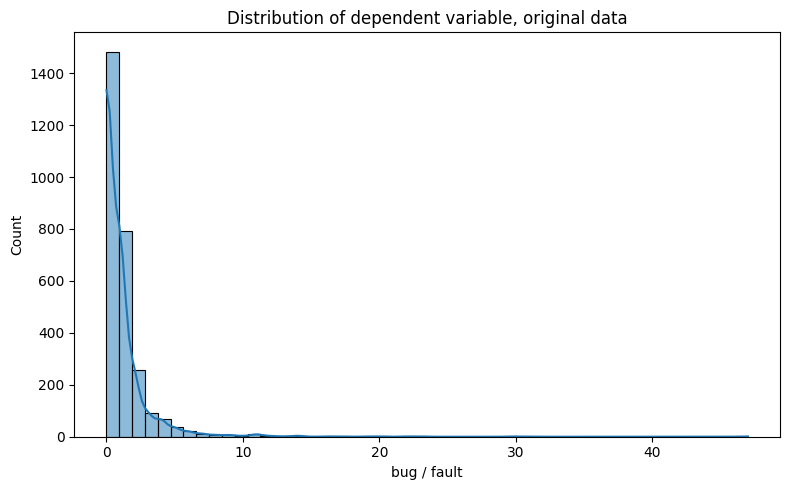

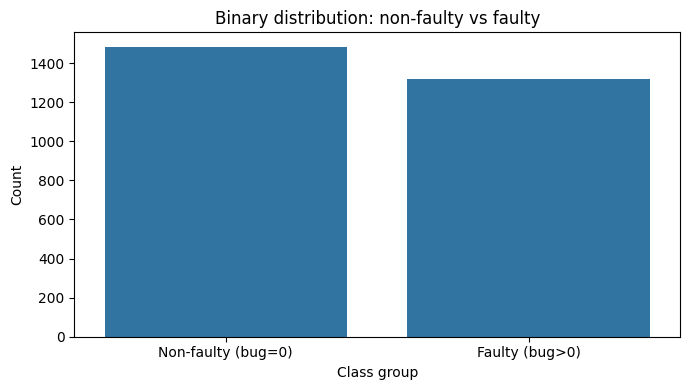

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(clean_df[TARGET], bins=50, kde=True)
plt.title("Distribution of dependent variable, original data")
plt.xlabel("bug / fault")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_distribution_original_bug.png", dpi=200)
plt.show()

plt.figure(figsize=(7, 4))
sns.countplot(x=(clean_df[TARGET] > 0).map({False: "Non-faulty (bug=0)", True: "Faulty (bug>0)"}))
plt.title("Binary distribution: non-faulty vs faulty")
plt.xlabel("Class group")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_binary_fault_distribution.png", dpi=200)
plt.show()

## 6. Ma trận tương quan

Bài báo nhấn mạnh các đặc trưng như `RFC`, `LOC`, `WMC` thường có quan hệ đáng chú ý với số lỗi. Cell này dùng correlation để kiểm tra lại trên 3 project đã chọn.

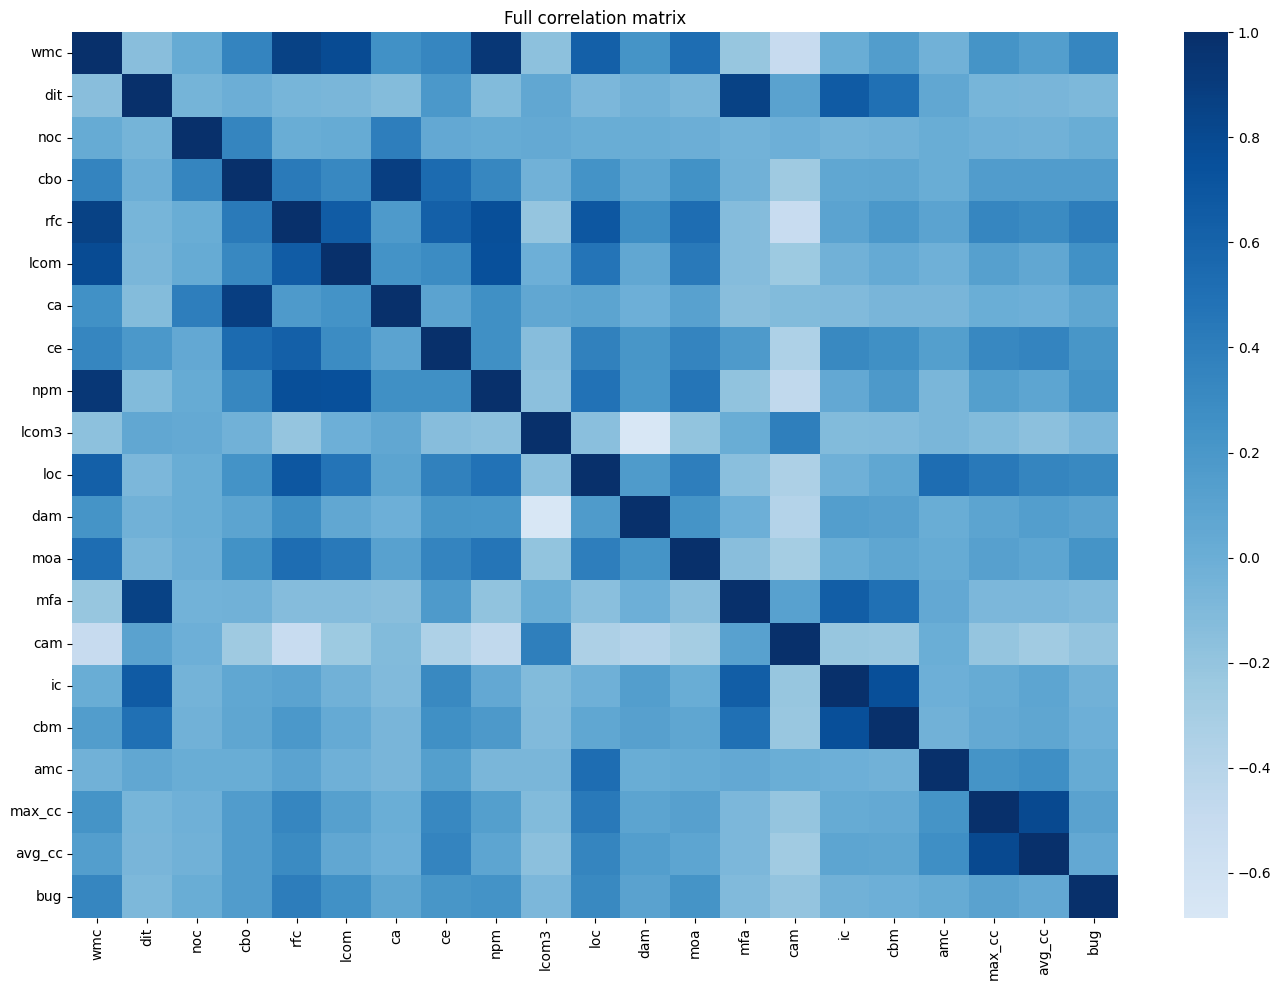

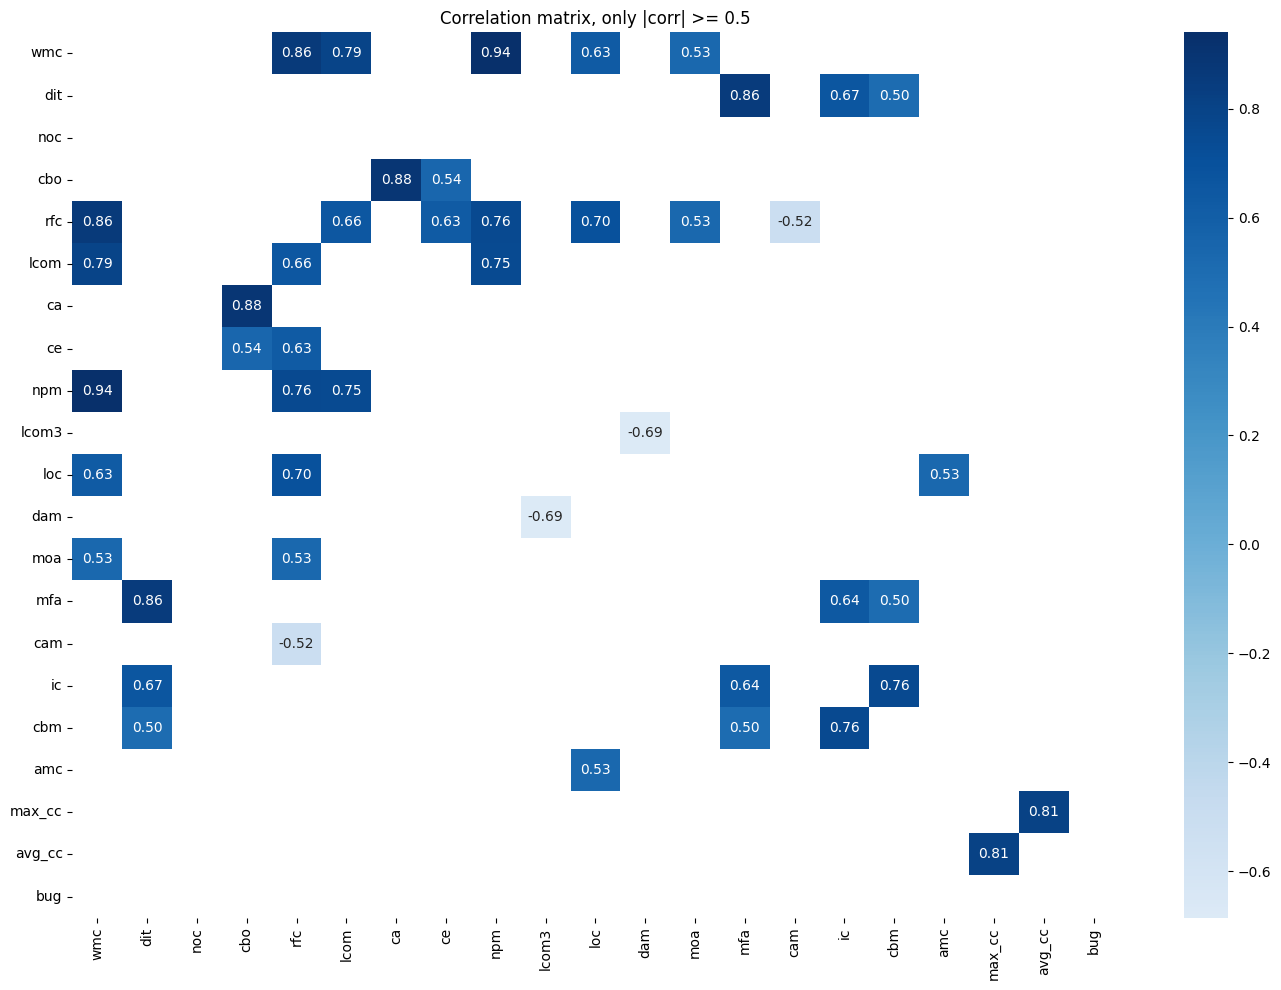

Top feature tương quan với bug theo trị tuyệt đối:


,corr_with_bug
rfc,0.411797
wmc,0.337218
loc,0.315212
lcom,0.254092
npm,0.241056
moa,0.230679
ce,0.215635
cam,-0.196038
cbo,0.162990
dam,0.108879


In [7]:
corr = clean_df[FEATURES + [TARGET]].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="Blues", center=0, annot=False)
plt.title("Full correlation matrix")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_full_correlation_matrix.png", dpi=200)
plt.show()

threshold = 0.5
strong_corr = corr.where((corr.abs() >= threshold) & (corr.abs() < 1.0))

plt.figure(figsize=(14, 10))
sns.heatmap(strong_corr, cmap="Blues", center=0, annot=True, fmt=".2f")
plt.title(f"Correlation matrix, only |corr| >= {threshold}")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_strong_correlation_matrix.png", dpi=200)
plt.show()

bug_corr = corr[TARGET].drop(TARGET).sort_values(key=lambda s: s.abs(), ascending=False)
bug_corr_df = bug_corr.to_frame("corr_with_bug")
print("Top feature tương quan với bug theo trị tuyệt đối:")
display(bug_corr_df)

bug_corr_df.to_csv(OUTPUT_DIR / "table_correlation_with_bug.csv")

## 9. SMOTEND-style oversampling

Bài báo dùng SMOTEND để xử lý mất cân bằng dữ liệu. Trong notebook này, ta cài trực tiếp phiên bản **SMOTEND-style** theo ý tưởng:

- Majority: class không lỗi, `bug = 0`
- Minority: class có lỗi, `bug > 0`
- Sinh thêm dữ liệu synthetic từ các mẫu faulty gần nhau
- Target synthetic là trung bình có trọng số theo khoảng cách giữa 2 mẫu

Tham số mặc định:

- `k = 5`
- `m = 6`, nghĩa là sinh đủ để cân bằng với majority nếu minority đang ít hơn
- `r = 2`, Minkowski distance tương đương Euclidean distance

In [9]:
def minkowski_distance(a: np.ndarray, b: np.ndarray, r: float = 2.0) -> float:
    return float(np.sum(np.abs(a - b) ** r) ** (1.0 / r))


def smotend_oversample(
    X: pd.DataFrame,
    y_bug: pd.Series,
    random_state: int = 42,
    k_neighbors: int = 5,
    m: int = 6,
    r: float = 2.0,
    n_parts: int = 6,
) -> tuple[pd.DataFrame, pd.Series, dict]:
    """
    SMOTEND-style oversampling for software defect number prediction.

    D_min = defective modules (bug > 0)
    D_maj = non-defective modules (bug == 0)

    numSynthetic = (|D_maj| - |D_min|) * m / n_parts

    Synthetic X:
        new = v1 + rand(0,1) * (v2 - v1)

    Synthetic y:
        y(new) = (d1*y(v2) + d2*y(v1)) / (d1+d2)
    """
    rng = np.random.default_rng(random_state)

    X_values = X.astype(float).to_numpy()
    y_values = y_bug.astype(float).to_numpy()

    minority_mask = y_values > 0
    majority_mask = y_values == 0

    X_min = X_values[minority_mask]
    y_min = y_values[minority_mask]
    n_min = len(X_min)
    n_maj = int(majority_mask.sum())

    summary = {
        "majority_non_faulty": n_maj,
        "minority_faulty": n_min,
        "k_neighbors": k_neighbors,
        "m": m,
        "r": r,
        "n_parts": n_parts,
        "synthetic_generated": 0,
        "note": "",
    }

    if n_min == 0:
        summary["note"] = "Không có faulty class, không thể SMOTEND."
        return X.copy(), y_bug.copy(), summary

    if n_min >= n_maj:
        summary["note"] = (
            "Faulty không ít hơn non-faulty trong subset này, "
            "SMOTEND theo định nghĩa paper không sinh thêm mẫu."
        )
        return X.copy(), y_bug.copy(), summary

    num_synthetic = int(round((n_maj - n_min) * m / n_parts))
    summary["synthetic_generated"] = num_synthetic

    if num_synthetic <= 0:
        summary["note"] = "num_synthetic <= 0, không sinh thêm mẫu."
        return X.copy(), y_bug.copy(), summary

    effective_k = min(k_neighbors + 1, n_min)
    nn = NearestNeighbors(n_neighbors=effective_k, metric="minkowski", p=r)
    nn.fit(X_min)
    neighbor_indices = nn.kneighbors(X_min, return_distance=False)

    # Bỏ chính nó nếu xuất hiện ở cột đầu.
    if effective_k > 1:
        neighbor_indices = neighbor_indices[:, 1:]
    else:
        neighbor_indices = neighbor_indices[:, :1]

    synthetic_X = []
    synthetic_y = []

    index = 0
    while len(synthetic_X) < num_synthetic:
        v1 = X_min[index]
        y1 = y_min[index]

        neighbors = neighbor_indices[index]
        if len(neighbors) == 0:
            chosen_neighbor_idx = index
        else:
            chosen_neighbor_idx = int(rng.choice(neighbors))

        v2 = X_min[chosen_neighbor_idx]
        y2 = y_min[chosen_neighbor_idx]

        lam = float(rng.random())
        new_x = v1 + lam * (v2 - v1)

        d1 = minkowski_distance(new_x, v1, r=r)
        d2 = minkowski_distance(new_x, v2, r=r)
        denom = d1 + d2

        if denom == 0:
            new_y = (y1 + y2) / 2.0
        else:
            new_y = (d1 * y2 + d2 * y1) / denom

        # bug là số lượng lỗi nên không để âm.
        new_y = max(0.0, float(new_y))

        synthetic_X.append(new_x)
        synthetic_y.append(new_y)

        index = (index + 1) % n_min

    X_syn = pd.DataFrame(synthetic_X, columns=X.columns)
    y_syn = pd.Series(synthetic_y, name=y_bug.name)

    X_balanced = pd.concat([X.reset_index(drop=True), X_syn], ignore_index=True)
    y_balanced = pd.concat([y_bug.reset_index(drop=True), y_syn], ignore_index=True)

    summary["note"] = "Đã sinh synthetic faulty samples bằng SMOTEND-style."
    return X_balanced, y_balanced, summary

## 10. Chuẩn bị dữ liệu cho 2 thí nghiệm

- **Experiment 1:** Không dùng SMOTEND.
- **Experiment 2:** Có dùng SMOTEND-style.

Cả hai thí nghiệm đều:

1. dùng 20 software metrics làm input,
2. dùng `bug` làm target,
3. dùng `log1p(bug)` để giảm lệch phải,
4. chuẩn hóa feature bằng `StandardScaler`,
5. chia train/test theo tỷ lệ 70/30.

In [10]:
def prepare_experiment_data(clean_df: pd.DataFrame, use_smotend: bool):
    X_raw = clean_df[FEATURES].copy()
    y_bug_raw = clean_df[TARGET].astype(float).copy()

    smotend_summary = None

    if use_smotend:
        X_work, y_bug_work, smotend_summary = smotend_oversample(
            X_raw,
            y_bug_raw,
            random_state=RANDOM_STATE,
            k_neighbors=5,
            m=6,
            r=2.0,
            n_parts=6,
        )
    else:
        X_work = X_raw.copy().reset_index(drop=True)
        y_bug_work = y_bug_raw.copy().reset_index(drop=True)
        smotend_summary = {
            "majority_non_faulty": int((y_bug_work == 0).sum()),
            "minority_faulty": int((y_bug_work > 0).sum()),
            "synthetic_generated": 0,
            "note": "Experiment không dùng SMOTEND."
        }

    y_log = np.log1p(y_bug_work.astype(float).to_numpy())

    stratify_labels = (y_bug_work > 0).astype(int)
    can_stratify = stratify_labels.nunique() == 2 and stratify_labels.value_counts().min() >= 2

    X_train_raw, X_test_raw, y_train, y_test, y_bug_train, y_bug_test = train_test_split(
        X_work,
        y_log,
        y_bug_work.to_numpy(),
        test_size=0.30,
        random_state=RANDOM_STATE,
        shuffle=True,
        stratify=stratify_labels if can_stratify else None,
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_test = scaler.transform(X_test_raw)

    data_info = {
        "X_work": X_work,
        "y_bug_work": y_bug_work,
        "y_log": y_log,
        "scaler": scaler,
        "smotend_summary": smotend_summary,
        "train_size": len(X_train),
        "test_size": len(X_test),
    }

    return X_train, X_test, y_train, y_test, y_bug_train, y_bug_test, data_info


X_train_no, X_test_no, y_train_no, y_test_no, y_bug_train_no, y_bug_test_no, info_no = prepare_experiment_data(clean_df, use_smotend=False)
X_train_sm, X_test_sm, y_train_sm, y_test_sm, y_bug_train_sm, y_bug_test_sm, info_sm = prepare_experiment_data(clean_df, use_smotend=True)

print("Experiment 1 - without SMOTEND")
print("Train:", X_train_no.shape, "Test:", X_test_no.shape)
print(info_no["smotend_summary"])

print("\nExperiment 2 - with SMOTEND-style")
print("Train:", X_train_sm.shape, "Test:", X_test_sm.shape)
print(info_sm["smotend_summary"])

Experiment 1 - without SMOTEND
Train: (1962, 20) Test: (841, 20)
{'majority_non_faulty': 1483, 'minority_faulty': 1320, 'synthetic_generated': 0, 'note': 'Experiment không dùng SMOTEND.'}

Experiment 2 - with SMOTEND-style
Train: (2076, 20) Test: (890, 20)
{'majority_non_faulty': 1483, 'minority_faulty': 1320, 'k_neighbors': 5, 'm': 6, 'r': 2.0, 'n_parts': 6, 'synthetic_generated': 163, 'note': 'Đã sinh synthetic faulty samples bằng SMOTEND-style.'}


## 11. Phân bố sau SMOTEND và sau log transformation



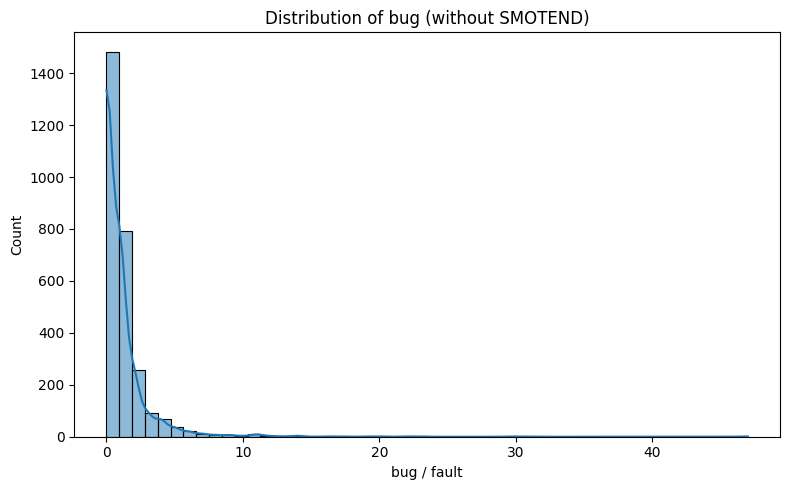

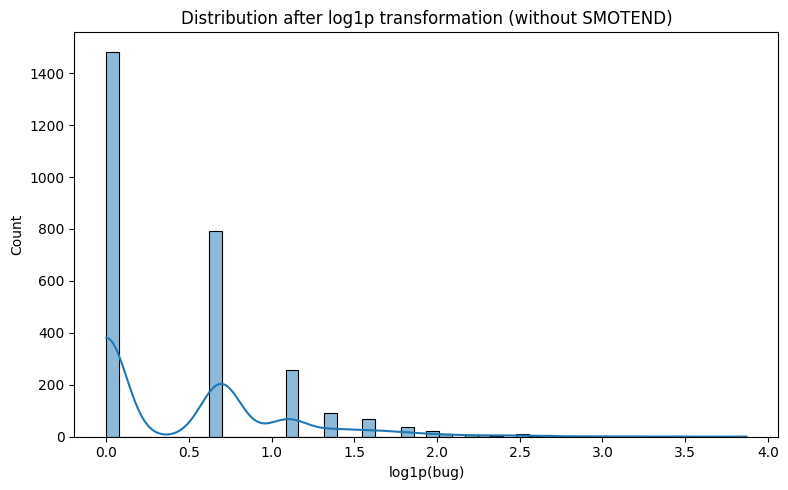

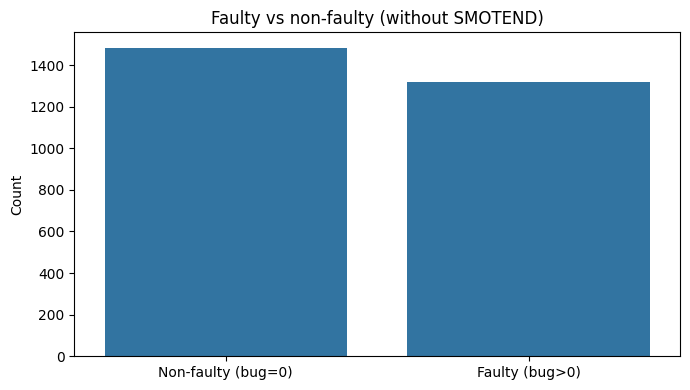

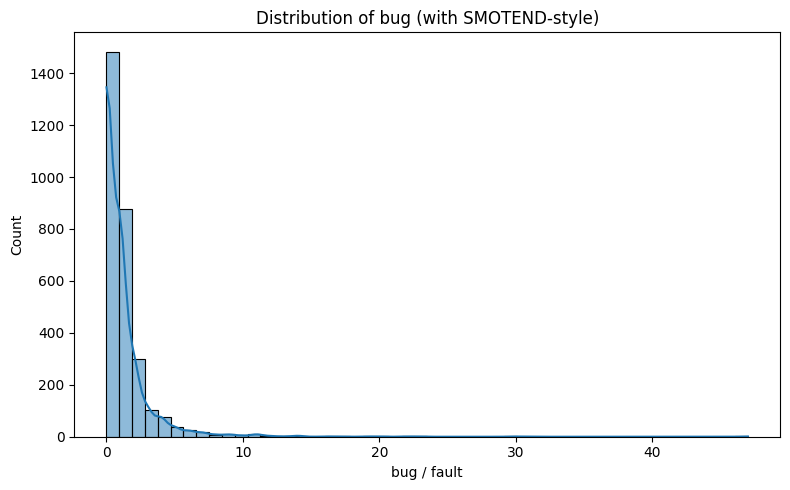

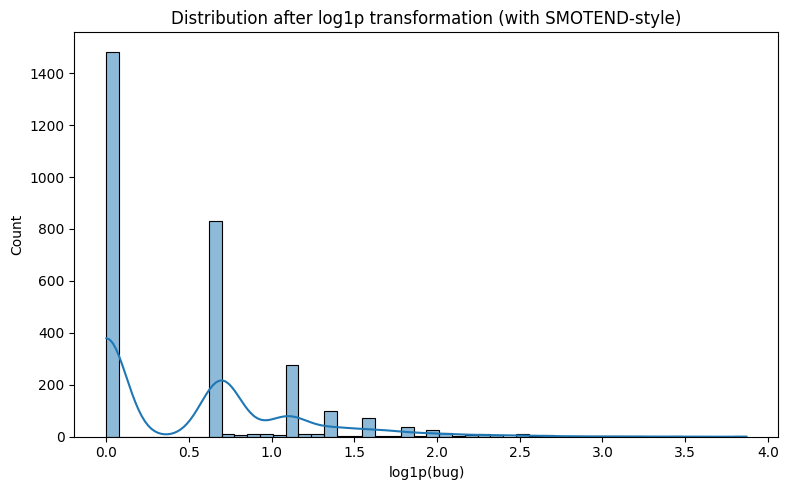

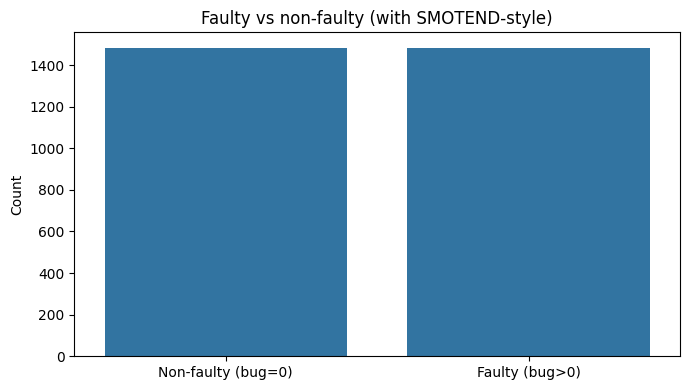

In [11]:
def plot_target_distribution(y_bug, y_log, title_suffix, filename_prefix):
    fig_df = pd.DataFrame({
        "bug": np.asarray(y_bug),
        "log1p_bug": np.asarray(y_log),
        "fault_group": np.where(np.asarray(y_bug) > 0, "Faulty (bug>0)", "Non-faulty (bug=0)")
    })

    plt.figure(figsize=(8, 5))
    sns.histplot(fig_df["bug"], bins=50, kde=True)
    plt.title(f"Distribution of bug {title_suffix}")
    plt.xlabel("bug / fault")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{filename_prefix}_bug_distribution.png", dpi=200)
    plt.show()

    plt.figure(figsize=(8, 5))
    sns.histplot(fig_df["log1p_bug"], bins=50, kde=True)
    plt.title(f"Distribution after log1p transformation {title_suffix}")
    plt.xlabel("log1p(bug)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{filename_prefix}_log_distribution.png", dpi=200)
    plt.show()

    plt.figure(figsize=(7, 4))
    sns.countplot(data=fig_df, x="fault_group")
    plt.title(f"Faulty vs non-faulty {title_suffix}")
    plt.xlabel("")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{filename_prefix}_faulty_non_faulty.png", dpi=200)
    plt.show()


plot_target_distribution(info_no["y_bug_work"], info_no["y_log"], "(without SMOTEND)", "exp1_without_smotend")
plot_target_distribution(info_sm["y_bug_work"], info_sm["y_log"], "(with SMOTEND-style)", "exp2_with_smotend")

## 12. Chia 20 feature thành 5 nhóm theo kiến trúc bài báo

Bài báo chia 20 software metrics thành 5 nhóm, mỗi nhóm 4 feature:

1. `WMC, DIT, NOC, CBO`
2. `RFC, LCOM, CA, CE`
3. `NPM, LCOM3, LOC, DAM`
4. `MOA, MFA, CAM, IC`
5. `CBM, AMC, MAX_CC, AVG_CC`

In [12]:
FEATURE_GROUPS = [
    ["wmc", "dit", "noc", "cbo"],
    ["rfc", "lcom", "ca", "ce"],
    ["npm", "lcom3", "loc", "dam"],
    ["moa", "mfa", "cam", "ic"],
    ["cbm", "amc", "max_cc", "avg_cc"],
]

feature_to_index = {feature: idx for idx, feature in enumerate(FEATURES)}
GROUP_INDICES = [[feature_to_index[f] for f in group] for group in FEATURE_GROUPS]

for i, group in enumerate(FEATURE_GROUPS, start=1):
    print(f"Group {i}:", group)


def split_groups_for_mlp(X_array: np.ndarray):
    return [X_array[:, idxs] for idxs in GROUP_INDICES]


def split_groups_for_cnn(X_array: np.ndarray):
    return [X_array[:, idxs].reshape(-1, 4, 1) for idxs in GROUP_INDICES]

Group 1: ['wmc', 'dit', 'noc', 'cbo']
Group 2: ['rfc', 'lcom', 'ca', 'ce']
Group 3: ['npm', 'lcom3', 'loc', 'dam']
Group 4: ['moa', 'mfa', 'cam', 'ic']
Group 5: ['cbm', 'amc', 'max_cc', 'avg_cc']


## 13. Xây dựng kiến trúc CNN và MLP

### CNN

Mỗi nhóm feature đi qua:

`Input -> Conv1D -> MaxPooling1D -> Dropout -> Flatten`

Sau đó 5 nhánh được merge rồi đưa qua Dense để dự đoán `log1p(bug)`.

### MLP

Mỗi nhóm feature đi qua:

`Input -> Dense -> Flatten`

Sau đó 5 nhánh được merge rồi đưa qua Dense để dự đoán `log1p(bug)`.

Cả hai model dùng:

- Activation: ReLU
- Kernel initializer: Glorot uniform
- Loss: MSE
- Optimizer: Adam

In [13]:
def build_cnn_model(learning_rate: float = 0.001) -> Model:
    inputs = []
    branches = []

    for i in range(5):
        inp = Input(shape=(4, 1), name=f"cnn_group_{i+1}")
        x = Conv1D(
            filters=16,
            kernel_size=2,
            activation="relu",
            kernel_initializer="glorot_uniform",
            name=f"conv_group_{i+1}"
        )(inp)
        x = MaxPooling1D(pool_size=2, name=f"maxpool_group_{i+1}")(x)
        x = Dropout(0.20, name=f"dropout_group_{i+1}")(x)
        x = Flatten(name=f"flatten_group_{i+1}")(x)

        inputs.append(inp)
        branches.append(x)

    merged = Concatenate(name="merge_cnn_groups")(branches)
    x = Dense(64, activation="relu", kernel_initializer="glorot_uniform", name="dense_1")(merged)
    x = Dropout(0.20, name="dropout_after_dense")(x)
    x = Dense(32, activation="relu", kernel_initializer="glorot_uniform", name="dense_2")(x)
    output = Dense(1, activation="linear", name="predicted_log1p_bug")(x)

    model = Model(inputs=inputs, outputs=output, name="CNN_fault_number_prediction")
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mse")
    return model


def build_mlp_model(learning_rate: float = 0.001) -> Model:
    inputs = []
    branches = []

    for i in range(5):
        inp = Input(shape=(4,), name=f"mlp_group_{i+1}")
        x = Dense(
            16,
            activation="relu",
            kernel_initializer="glorot_uniform",
            name=f"dense_group_{i+1}"
        )(inp)
        x = Flatten(name=f"flatten_mlp_group_{i+1}")(x)

        inputs.append(inp)
        branches.append(x)

    merged = Concatenate(name="merge_mlp_groups")(branches)
    x = Dense(64, activation="relu", kernel_initializer="glorot_uniform", name="dense_1")(merged)
    x = Dropout(0.20, name="dropout_after_dense")(x)
    x = Dense(32, activation="relu", kernel_initializer="glorot_uniform", name="dense_2")(x)
    output = Dense(1, activation="linear", name="predicted_log1p_bug")(x)

    model = Model(inputs=inputs, outputs=output, name="MLP_fault_number_prediction")
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mse")
    return model


print("CNN summary")
build_cnn_model().summary()
print("\nMLP summary")
build_mlp_model().summary()

CNN summary


Model: "CNN_fault_number_prediction"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cnn_group_1         │ (None, 4, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_group_2         │ (None, 4, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_group_3         │ (None, 4, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_group_4         │ (None, 4, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_group_5         │ (None, 4, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_group_1        │ (None, 3, 16)     │         48 │ cnn_group_1[0][0] │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_group_2        │ (None, 3, 16)     │         48 │ cnn_group_2[0][0] │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_group_3        │ (None, 3, 16)     │         48 │ cnn_group_3[0][0] │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_group_4        │ (None, 3, 16)     │         48 │ cnn_group_4[0][0] │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_group_5        │ (None, 3, 16)     │         48 │ cnn_group_5[0][0] │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_group_1     │ (None, 1, 16)     │          0 │ conv_group_1[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_group_2     │ (None, 1, 16)     │          0 │ conv_group_2[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_group_3     │ (None, 1, 16)     │          0 │ conv_group_3[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_group_4     │ (None, 1, 16)     │          0 │ conv_group_4[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_group_5     │ (None, 1, 16)     │          0 │ conv_group_5[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_group_1     │ (None, 1, 16)     │          0 │ maxpool_group_1[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_group_2     │ (None, 1, 16)     │          0 │ maxpool_group_2[

 Total params: 7,537 (29.44 KB)

 Trainable params: 7,537 (29.44 KB)

...

Model: "MLP_fault_number_prediction"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mlp_group_1         │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_group_2         │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_group_3         │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_group_4         │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_group_5         │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_group_1       │ (None, 16)        │         80 │ mlp_group_1[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_group_2       │ (None, 16)        │         80 │ mlp_group_2[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_group_3       │ (None, 16)        │         80 │ mlp_group_3[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_group_4       │ (None, 16)        │         80 │ mlp_group_4[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_group_5       │ (None, 16)        │         80 │ mlp_group_5[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_mlp_group_1 │ (None, 16)        │          0 │ dense_group_1[0]… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_mlp_group_2 │ (None, 16)        │          0 │ dense_group_2[0]… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_mlp_group_3 │ (None, 16)        │          0 │ dense_group_3[0]… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_mlp_group_4 │ (None, 16)        │          0 │ dense_group_4[0]… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_mlp_group_5 │ (None, 16)        │          0 │ dense_group_5[0]… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ merge_mlp_groups    │ (None, 80)        │          0 │ flatten_mlp_grou… │
│ (Concatenate)       │                   │            │ flatten_mlp_grou… │
│                     │                   │            │ flatten_mlp_grou… │
│                     │                   │            │ flatten_mlp_grou

 Total params: 7,697 (30.07 KB)

 Trainable params: 7,697 (30.07 KB)

 Non-trainable params: 0 (0.00 B)

## 14. Hàm đánh giá



In [14]:
def safe_kendall(y_true, y_pred):
    result = kendalltau(np.ravel(y_true), np.ravel(y_pred))
    if result.correlation is None or np.isnan(result.correlation):
        return 0.0
    return float(result.correlation)


def evaluate_regression(y_true_log, y_pred_log):
    y_pred_log = np.ravel(y_pred_log)
    y_true_log = np.ravel(y_true_log)

    y_true_bug = np.expm1(y_true_log)
    y_pred_bug = np.maximum(0, np.expm1(y_pred_log))

    return {
        "Kendall": round(safe_kendall(y_true_log, y_pred_log), 4),
        "MSE": round(mean_squared_error(y_true_log, y_pred_log), 4),
        "MSE_original_bug_scale": round(mean_squared_error(y_true_bug, y_pred_bug), 4),
    }


def train_deep_model(
    model_name: str,
    experiment_name: str,
    X_train: np.ndarray,
    X_test: np.ndarray,
    y_train: np.ndarray,
    y_test: np.ndarray,
    epochs: int = 100,
    batch_size: int = 16,
    learning_rate: float = 0.001,
):
    tf.keras.backend.clear_session()
    tf.random.set_seed(RANDOM_STATE)

    if model_name.upper() == "CNN":
        model = build_cnn_model(learning_rate=learning_rate)
        X_train_input = split_groups_for_cnn(X_train)
        X_test_input = split_groups_for_cnn(X_test)
    elif model_name.upper() == "MLP":
        model = build_mlp_model(learning_rate=learning_rate)
        X_train_input = split_groups_for_mlp(X_train)
        X_test_input = split_groups_for_mlp(X_test)
    else:
        raise ValueError("model_name phải là CNN hoặc MLP")

    callbacks = [
        EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True,
            verbose=0
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=7,
            min_lr=1e-5,
            verbose=0
        )
    ]

    print(f"\nTraining {model_name} - {experiment_name}")

    history = model.fit(
        X_train_input,
        y_train,
        validation_split=0.20,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1,
    )

    pred_train = model.predict(X_train_input, verbose=0)
    pred_test = model.predict(X_test_input, verbose=0)

    rows = [
        {"Experiment": experiment_name, "Model": model_name, "Dataset": "Train", **evaluate_regression(y_train, pred_train)},
        {"Experiment": experiment_name, "Model": model_name, "Dataset": "Test", **evaluate_regression(y_test, pred_test)},
    ]

    return model, history, rows

## 15. Train CNN và MLP trước/sau SMOTEND



In [15]:
EPOCHS = 100
BATCH_SIZE = 16
LEARNING_RATE = 0.001

all_results = []
histories = {}
models = {}

experiments = [
    ("Experiment 1 - without SMOTEND", X_train_no, X_test_no, y_train_no, y_test_no),
    ("Experiment 2 - with SMOTEND", X_train_sm, X_test_sm, y_train_sm, y_test_sm),
]

for exp_name, Xtr, Xte, ytr, yte in experiments:
    for model_name in ["CNN", "MLP"]:
        model, history, rows = train_deep_model(
            model_name=model_name,
            experiment_name=exp_name,
            X_train=Xtr,
            X_test=Xte,
            y_train=ytr,
            y_test=yte,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            learning_rate=LEARNING_RATE,
        )
        key = f"{model_name}_{exp_name}"
        models[key] = model
        histories[key] = history
        all_results.extend(rows)

deep_results_df = pd.DataFrame(all_results)
display(deep_results_df)
deep_results_df.to_csv(OUTPUT_DIR / "table_deep_learning_results.csv", index=False)



Training CNN - Experiment 1 - without SMOTEND
Epoch 1/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4318 - val_loss: 0.3344 - learning_rate: 0.0010
Epoch 2/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3257 - val_loss: 0.3158 - learning_rate: 0.0010
Epoch 3/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3132 - val_loss: 0.3224 - learning_rate: 0.0010
Epoch 4/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3063 - val_loss: 0.3195 - learning_rate: 0.0010
Epoch 5/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3209 - val_loss: 0.3171 - learning_rate: 0.0010
Epoch 6/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3058 - val_loss: 0.3122 - learning_rate: 0.0010
Epoch 7/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3077 - val_loss: 0.3139 - learning_rate: 0.0010
Epoch 8/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3116 - val_loss: 0.3195 - learning_rate: 0.0010
Epoch 9/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3161 - val_loss: 0.

,Experiment,Model,Dataset,Kendall,MSE,MSE_original_bug_scale
0,Experiment 1 - without SMOTEND,CNN,Train,0.3074,0.2622,3.7091
1,Experiment 1 - without SMOTEND,CNN,Test,0.2001,0.3127,3.3291
2,Experiment 1 - without SMOTEND,MLP,Train,0.3909,0.2318,3.4201
3,Experiment 1 - without SMOTEND,MLP,Test,0.2364,0.3055,3.2419
4,Experiment 2 - with SMOTEND,CNN,Train,0.3389,0.2640,3.8628
5,Experiment 2 - with SMOTEND,CNN,Test,0.2464,0.3088,3.3653
6,Experiment 2 - with SMOTEND,MLP,Train,0.4166,0.2357,3.6556
7,Experiment 2 - with SMOTEND,MLP,Test,0.2832,0.2985,3.2277


## 16. Biểu đồ Training Loss và Validation Loss



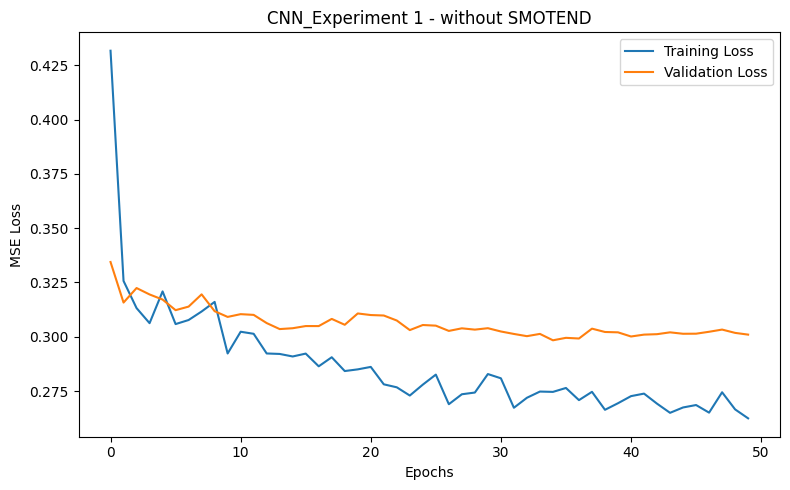

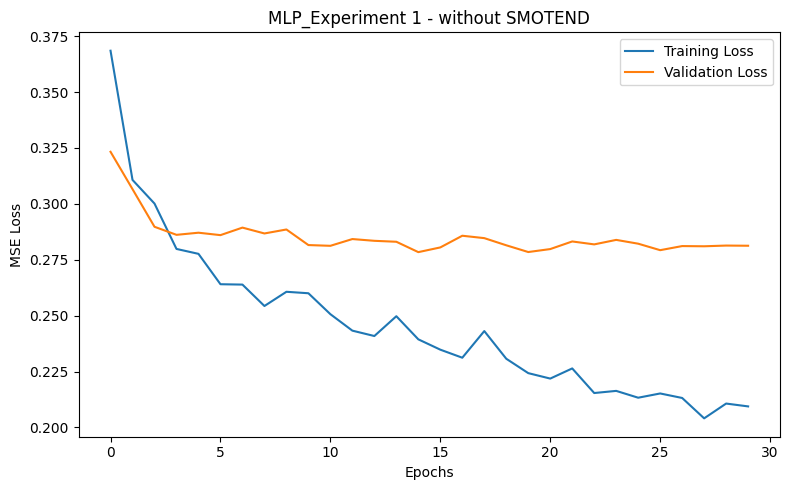

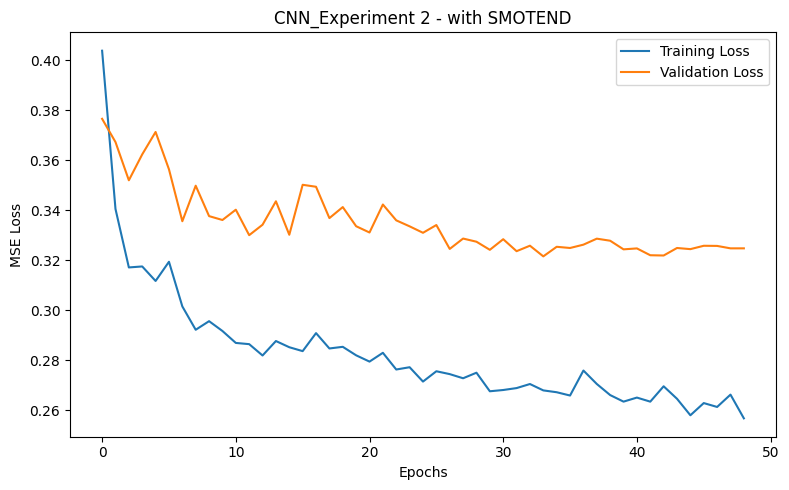

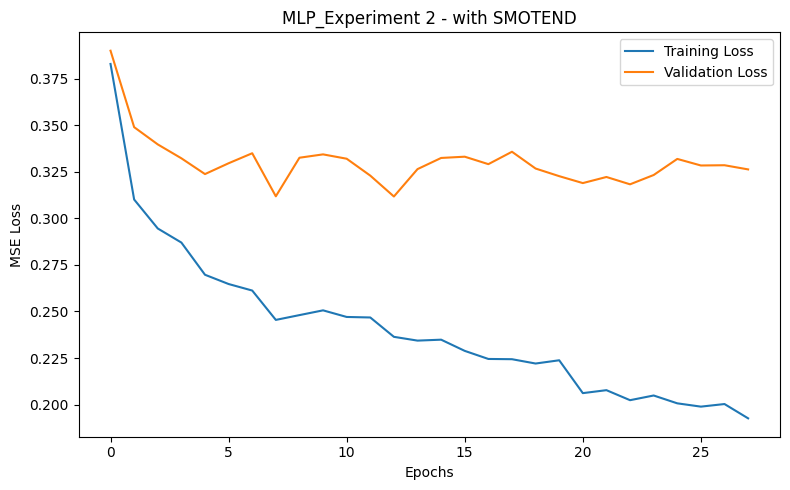

,Model_Experiment,epochs_ran,best_epoch_by_val_loss,final_train_loss,final_val_loss,final_val_train_gap,best_train_loss,best_val_loss,best_val_train_gap
0,CNN_Experiment 1 - without SMOTEND,50,35,0.2624,0.3010,0.0386,0.2746,0.2984,0.0238
1,MLP_Experiment 1 - without SMOTEND,30,15,0.2094,0.2813,0.0719,0.2394,0.2784,0.0390
2,CNN_Experiment 2 - with SMOTEND,49,34,0.2567,0.3247,0.0680,0.2679,0.3215,0.0536
3,MLP_Experiment 2 - with SMOTEND,28,13,0.1926,0.3262,0.1336,0.2364,0.3117,0.0753


In [16]:
def plot_loss(history, title: str, filename: str):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(title)
    plt.xlabel("Epochs")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=200)
    plt.show()


loss_diagnostics = []

for key, history in histories.items():
    filename = key.lower().replace(" ", "_").replace("-", "").replace("/", "_") + ".png"
    plot_loss(history, key, filename)

    loss_values = np.array(history.history["loss"])
    val_loss_values = np.array(history.history["val_loss"])
    best_epoch = int(np.argmin(val_loss_values) + 1)
    final_gap = float(val_loss_values[-1] - loss_values[-1])
    best_gap = float(val_loss_values[best_epoch - 1] - loss_values[best_epoch - 1])

    loss_diagnostics.append({
        "Model_Experiment": key,
        "epochs_ran": len(loss_values),
        "best_epoch_by_val_loss": best_epoch,
        "final_train_loss": round(float(loss_values[-1]), 4),
        "final_val_loss": round(float(val_loss_values[-1]), 4),
        "final_val_train_gap": round(final_gap, 4),
        "best_train_loss": round(float(loss_values[best_epoch - 1]), 4),
        "best_val_loss": round(float(val_loss_values[best_epoch - 1]), 4),
        "best_val_train_gap": round(best_gap, 4),
    })

loss_diagnostics_df = pd.DataFrame(loss_diagnostics)
display(loss_diagnostics_df)
loss_diagnostics_df.to_csv(OUTPUT_DIR / "table_loss_diagnostics.csv", index=False)

## 17. Baseline Machine Learning: DTR và SVR



In [17]:
def train_ml_baselines(experiment_name, X_train, X_test, y_train, y_test):
    baseline_models = {
        "DTR": DecisionTreeRegressor(random_state=RANDOM_STATE),
        "SVR": SVR(kernel="rbf", C=10.0, epsilon=0.1),
    }

    rows = []
    trained = {}

    for name, model in baseline_models.items():
        print(f"Training {name} - {experiment_name}")
        model.fit(X_train, y_train)
        trained[name] = model

        pred_train = model.predict(X_train)
        pred_test = model.predict(X_test)

        rows.append({"Experiment": experiment_name, "Model": name, "Dataset": "Train", **evaluate_regression(y_train, pred_train)})
        rows.append({"Experiment": experiment_name, "Model": name, "Dataset": "Test", **evaluate_regression(y_test, pred_test)})

    return trained, rows


ml_results = []
ml_models = {}

for exp_name, Xtr, Xte, ytr, yte in experiments:
    trained, rows = train_ml_baselines(exp_name, Xtr, Xte, ytr, yte)
    ml_models[exp_name] = trained
    ml_results.extend(rows)

ml_results_df = pd.DataFrame(ml_results)
display(ml_results_df)
ml_results_df.to_csv(OUTPUT_DIR / "table_ml_baseline_results.csv", index=False)

Training DTR - Experiment 1 - without SMOTEND
Training SVR - Experiment 1 - without SMOTEND
Training DTR - Experiment 2 - with SMOTEND
Training SVR - Experiment 2 - with SMOTEND


,Experiment,Model,Dataset,Kendall,MSE,MSE_original_bug_scale
0,Experiment 1 - without SMOTEND,DTR,Train,0.9258,0.0185,0.0739
1,Experiment 1 - without SMOTEND,DTR,Test,0.1091,0.5353,7.2001
2,Experiment 1 - without SMOTEND,SVR,Train,0.5013,0.1773,1.3374
3,Experiment 1 - without SMOTEND,SVR,Test,0.2413,0.3367,3.4951
4,Experiment 2 - with SMOTEND,DTR,Train,0.9299,0.0185,0.0803
5,Experiment 2 - with SMOTEND,DTR,Test,0.1928,0.5846,13.5349
6,Experiment 2 - with SMOTEND,SVR,Train,0.5100,0.1785,1.3599
7,Experiment 2 - with SMOTEND,SVR,Test,0.2876,0.3166,3.2407


## 18. Tổng hợp kết quả và biểu đồ so sánh

Report nên đưa ít nhất 2 bảng:

1. Bảng CNN/MLP trước và sau SMOTEND.
2. Bảng so sánh CNN/MLP với DTR/SVR.

Biểu đồ nên có:

1. So sánh Test MSE.
2. So sánh Test Kendall.

,Experiment,Model,Dataset,Kendall,MSE,MSE_original_bug_scale
0,Experiment 1 - without SMOTEND,CNN,Test,0.2001,0.3127,3.3291
1,Experiment 1 - without SMOTEND,CNN,Train,0.3074,0.2622,3.7091
2,Experiment 1 - without SMOTEND,DTR,Test,0.1091,0.5353,7.2001
3,Experiment 1 - without SMOTEND,DTR,Train,0.9258,0.0185,0.0739
4,Experiment 1 - without SMOTEND,MLP,Test,0.2364,0.3055,3.2419
5,Experiment 1 - without SMOTEND,MLP,Train,0.3909,0.2318,3.4201
6,Experiment 1 - without SMOTEND,SVR,Test,0.2413,0.3367,3.4951
7,Experiment 1 - without SMOTEND,SVR,Train,0.5013,0.1773,1.3374
8,Experiment 2 - with SMOTEND,CNN,Test,0.2464,0.3088,3.3653
9,Experiment 2 - with SMOTEND,CNN,Train,0.3389,0.2640,3.8628


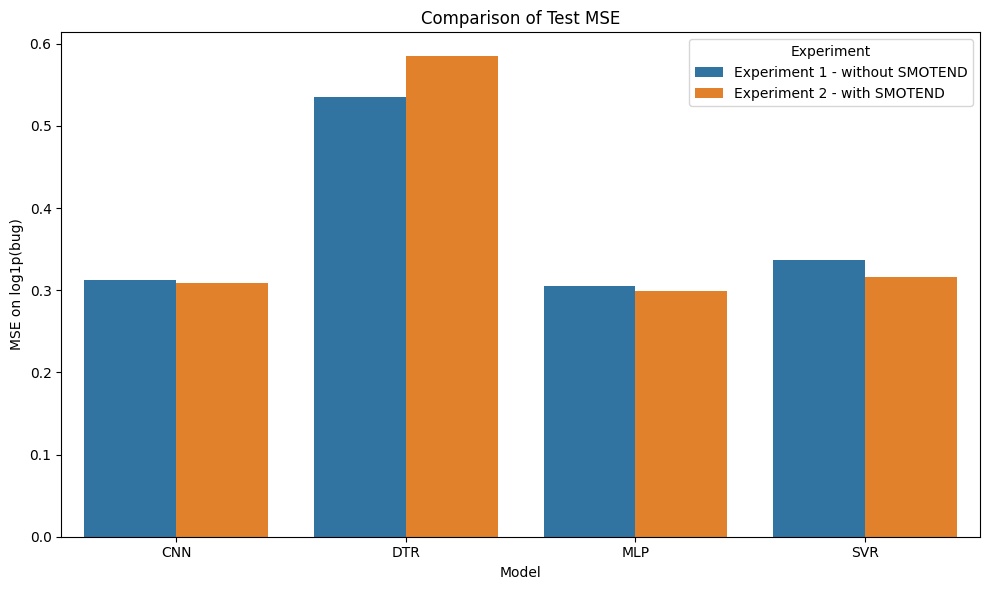

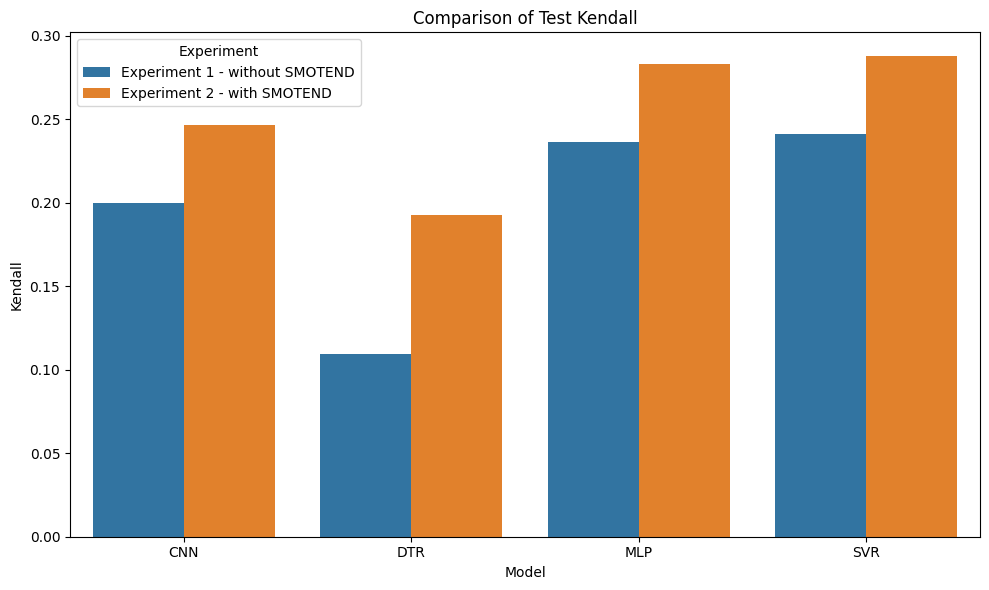

Pivot Test MSE:


Experiment,Experiment 1 - without SMOTEND,Experiment 2 - with SMOTEND
Model,,
CNN,0.3127,0.3088
DTR,0.5353,0.5846
MLP,0.3055,0.2985
SVR,0.3367,0.3166


Pivot Test Kendall:


Experiment,Experiment 1 - without SMOTEND,Experiment 2 - with SMOTEND
Model,,
CNN,0.2001,0.2464
DTR,0.1091,0.1928
MLP,0.2364,0.2832
SVR,0.2413,0.2876


In [18]:
final_results_df = pd.concat([deep_results_df, ml_results_df], ignore_index=True)
final_results_df = final_results_df.sort_values(["Experiment", "Model", "Dataset"]).reset_index(drop=True)
display(final_results_df)
final_results_df.to_csv(OUTPUT_DIR / "final_all_results.csv", index=False)

test_results = final_results_df[final_results_df["Dataset"] == "Test"].copy()

plt.figure(figsize=(10, 6))
sns.barplot(data=test_results, x="Model", y="MSE", hue="Experiment")
plt.title("Comparison of Test MSE")
plt.xlabel("Model")
plt.ylabel("MSE on log1p(bug)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_compare_test_mse.png", dpi=200)
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=test_results, x="Model", y="Kendall", hue="Experiment")
plt.title("Comparison of Test Kendall")
plt.xlabel("Model")
plt.ylabel("Kendall")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_compare_test_kendall.png", dpi=200)
plt.show()

# Bảng pivot đẹp cho report
pivot_test_mse = test_results.pivot_table(index="Model", columns="Experiment", values="MSE")
pivot_test_kendall = test_results.pivot_table(index="Model", columns="Experiment", values="Kendall")

print("Pivot Test MSE:")
display(pivot_test_mse)

print("Pivot Test Kendall:")
display(pivot_test_kendall)

pivot_test_mse.to_csv(OUTPUT_DIR / "table_pivot_test_mse.csv")
pivot_test_kendall.to_csv(OUTPUT_DIR / "table_pivot_test_kendall.csv")